<center>Universidade Federal de Viçosa</center>
<center>Coordenadoria de Educação Aberta e a Distância</center>
<center>Inteligência Artificial e Computacional</center>
<center>ELT578 - Análise de Imagens e Visão Computacional</center>

**<center>Desafio 4: Detecção automática de ponto</center>**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

Pontos detectados (ordenados): [[109. 599.]
 [405. 457.]
 [341. 608.]
 [109. 599.]]


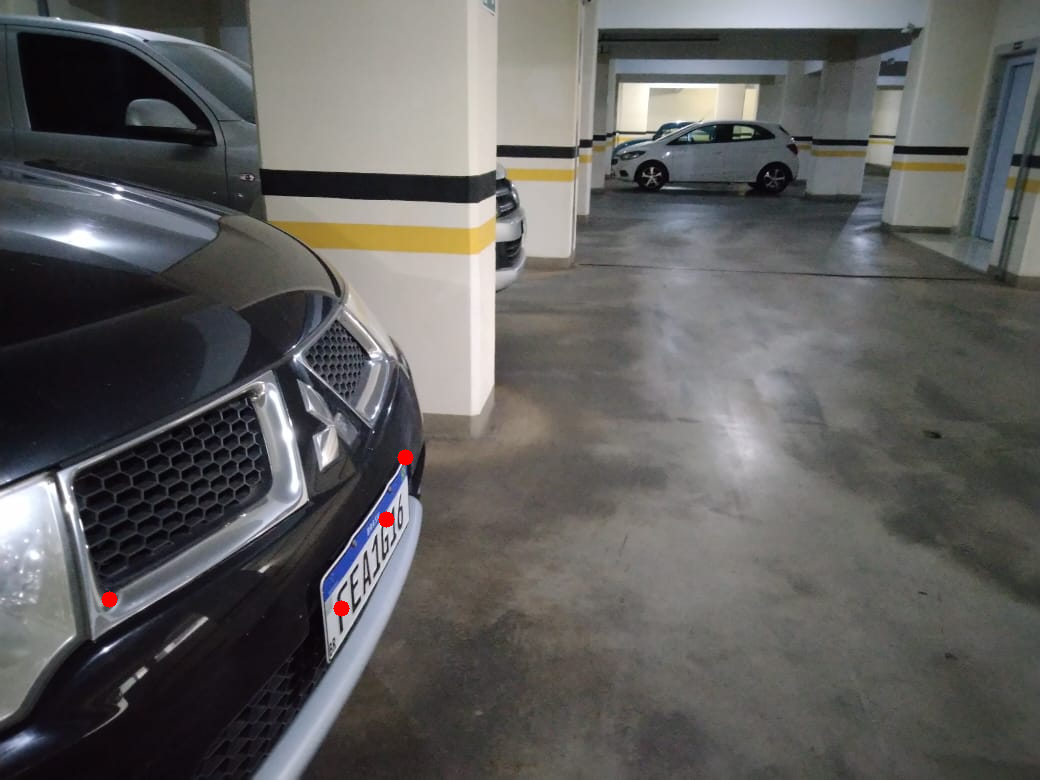

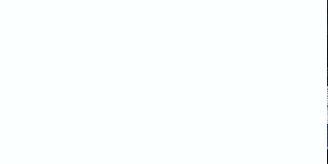

True

In [3]:
# Carregar imagem
I1 = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/placa_lateral1.jpg')
gray = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)

# Detectar cantos (Shi-Tomasi)
corners = cv2.goodFeaturesToTrack(gray, maxCorners=4, qualityLevel=0.1, minDistance=50)
corners = np.int_(corners).reshape(-1, 2)

# Função para ordenar os pontos (TL, TR, BR, BL)
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # Top-left
    rect[2] = pts[np.argmax(s)]  # Bottom-right
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # Top-right
    rect[3] = pts[np.argmax(diff)]  # Bottom-left
    return rect

# Ordenar os pontos detectados
pt1 = order_points(corners)

# Calcular largura e altura reais do quadrilátero detectado
width_top = np.linalg.norm(pt1[0] - pt1[1])
width_bottom = np.linalg.norm(pt1[3] - pt1[2])
max_width = int(max(width_top, width_bottom))

height_left = np.linalg.norm(pt1[0] - pt1[3])
height_right = np.linalg.norm(pt1[1] - pt1[2])
max_height = int(max(height_left, height_right))

# Pontos de destino (dinâmicos)
pt2 = np.float32([[0, 0], [max_width-1, 0],
                  [max_width-1, max_height-1], [0, max_height-1]])

# Matriz de transformação
M = cv2.getPerspectiveTransform(pt1, pt2)
IT1 = cv2.warpPerspective(I1, M, (max_width, max_height))

# Desenhar pontos detectados na imagem original
for x, y in corners:
    cv2.circle(I1, (x, y), 8, (0, 0, 255), -1)

# Exibir resultados
print("Pontos detectados (ordenados):", pt1)
cv2_imshow(I1)  # imagem com pontos
cv2_imshow(IT1) # placa corrigida
cv2.imwrite('PLACAL4_CORRIGIDA.png', IT1)


#**RNC**

In [4]:
!pip install ultralytics easyocr opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.1/292.1 kB 22.2 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO
import easyocr
import cv2
import numpy as np
import glob
import os
from google.colab.patches import cv2_imshow

# Caminho das imagens
carros_dir = "/content/drive/MyDrive/ELT578/SEMANA_2/carros/"

# Inicializa OCR
reader = easyocr.Reader(['en'])

# Carrega modelo YOLOv8 genérico
model = YOLO("yolov8n.pt")

# Lista todas as imagens
imagens = glob.glob(os.path.join(carros_dir, "*.jpg"))

for img_path in imagens:
    img = cv2.imread(img_path)

    # Predição YOLOv8
    results = model.predict(img, imgsz=640, conf=0.25, verbose=False)

    # Cada objeto detectado
    for result in results:
        if len(result.boxes) == 0:
            continue

        for box, score, cls in zip(result.boxes.xyxy, result.boxes.conf, result.boxes.cls):
            x1, y1, x2, y2 = map(int, box)

            # Recorta a região da placa
            placa_crop = img[y1:y2, x1:x2]

            # OCR
            ocr_result = reader.readtext(placa_crop)
            texto = ocr_result[0][1] if ocr_result else "N/A"

            # Desenha retângulo e texto
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, texto, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Mostra a imagem anotada no Colab
    cv2_imshow(img)


Output hidden; open in https://colab.research.google.com to view.

In [7]:
!git clone https://github.com/Muhammad-Zeerak-Khan/Automatic-License-Plate-Recognition-using-YOLOv8.git


fatal: destination path 'Automatic-License-Plate-Recognition-using-YOLOv8' already exists and is not an empty directory.


In [8]:
from ultralytics import YOLO
import easyocr
import cv2
import numpy as np
import glob
import os
from google.colab.patches import cv2_imshow

# Monte o Drive
from google.colab import drive
drive.mount('/content/drive')

# Caminho das imagens
carros_dir = "/content/drive/MyDrive/ELT578/SEMANA_2/carros/"

# Lista as imagens
imagens = glob.glob(os.path.join(carros_dir, "*.*"))
print(f"{len(imagens)} imagens encontradas")

# Inicializa OCR e modelo YOLO para placas
reader = easyocr.Reader(['en'])
model_path = "/content/Automatic-License-Plate-Recognition-using-YOLOv8/license_plate_detector.pt"
model = YOLO(model_path)

# Loop
for img_path in imagens:
    img = cv2.imread(img_path)
    if img is None:
        print(f"Erro ao ler {img_path}")
        continue

    results = model.predict(img, imgsz=640, conf=0.25, verbose=False)

    for result in results:
        for box in result.boxes.xyxy:
            x1, y1, x2, y2 = map(int, box)
            placa_crop = img[y1:y2, x1:x2]

            # OCR
            ocr_result = reader.readtext(placa_crop)
            texto = ocr_result[0][1] if ocr_result else "N/A"

            # Anotação
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, texto, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2_imshow(img)

Output hidden; open in https://colab.research.google.com to view.